In [12]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("automation_projects.csv")

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   project_id              50000 non-null  str    
 1   company_id              50000 non-null  str    
 2   project_name            50000 non-null  str    
 3   start_date              50000 non-null  str    
 4   completion_date         35064 non-null  str    
 5   project_status          50000 non-null  str    
 6   automation_type         50000 non-null  str    
 7   robots_deployed         50000 non-null  int64  
 8   budget_usd              50000 non-null  int64  
 9   annual_savings_usd      50000 non-null  int64  
 10  roi_percent             50000 non-null  float64
 11  department              50000 non-null  str    
 12  implementation_partner  50000 non-null  str    
 13  country                 50000 non-null  str    
 14  industry                50000 non-null  str    
 

In [15]:
df['roi'] = df['roi_percent'].apply(lambda x: x / 100)
df.drop('roi_percent', axis = 1, inplace = True)

In [16]:
df.head()

,project_id,company_id,project_name,start_date,completion_date,project_status,automation_type,robots_deployed,budget_usd,annual_savings_usd,department,implementation_partner,country,industry,employee_hours_saved,ai_enabled,cloud_deployment,roi
0,PRJ000001,CMP04872,Prism Automation Initiative,2017-04-23,NaN,Active,Customer Onboarding,27,10889,17248,Content Moderation,Cyient,Vietnam,Government & Public Sector,69944,Yes,Yes,1.584
1,PRJ000002,CMP04395,Sentinel Process Reengineering,2023-07-29,2024-03-16,Completed,Claims Processing,44,1069470,579652,Customer Onboarding,Tech Mahindra,South Africa,Mining & Metals,31856,No,Yes,0.542
2,PRJ000003,CMP01477,Sentinel Task Automation,2021-03-10,2022-12-22,Completed,Email Automation,18,43509,23494,Finance & Accounting,EXL Service,United States,Nonprofit & NGO,5935,No,Yes,0.540
3,PRJ000004,CMP00578,Robust Automation Platform,2023-12-30,2024-12-15,Completed,Order Processing,6,99001,107812,Finance & Accounting,Birlasoft,Italy,Banking & Financial Services,9491,Yes,Yes,1.089
4,PRJ000005,CMP02586,Nexus Automation Platform,2024-09-08,NaN,Active,Customer Onboarding,21,122055,255949,Sales & Marketing,Capgemini,Denmark,Aerospace & Defense,26693,Yes,Yes,2.097


In [17]:
df.project_status.unique()

<StringArray>
['Active', 'Completed', 'Planned']
Length: 3, dtype: str

# 1. Annual Savings Analysis

In [18]:
savings = df['annual_savings_usd']

print(f"Mean:    {savings.mean():,.2f}")
print(f"Median:  {savings.median():,.2f}")
print(f"Q1 (25%): {savings.quantile(0.25):,.2f}")
print(f"Q2 (50%): {savings.quantile(0.50):,.2f}")
print(f"Q3 (75%): {savings.quantile(0.75):,.2f}")

Mean:    318,086.36
Median:  157,912.50
Q1 (25%): 71,082.00
Q2 (50%): 157,912.50
Q3 (75%): 351,505.50


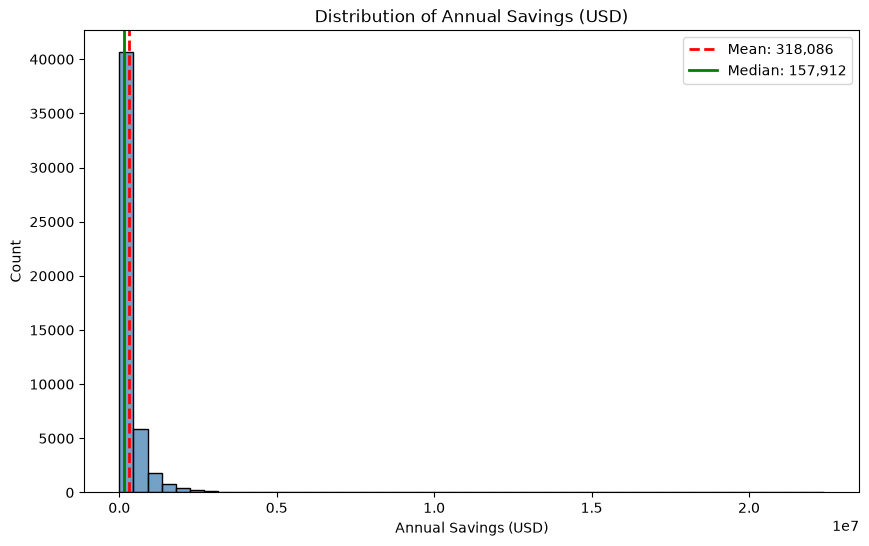

In [19]:
mean_val = df['annual_savings_usd'].mean()
median_val = df['annual_savings_usd'].median()

plt.figure(figsize=(10, 6))
sns.histplot(df['annual_savings_usd'], bins=50, color='steelblue')

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {mean_val:,.0f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2,
            label=f'Median: {median_val:,.0f}')

plt.title('Distribution of Annual Savings (USD)')
plt.xlabel('Annual Savings (USD)')
plt.ylabel('Count')
plt.legend()
plt.show()

In [20]:
# Standardize annual_savings_usd (z-score: (x - mean) / std)
mean_savings = df['annual_savings_usd'].mean()
std_savings = df['annual_savings_usd'].std()

df['annual_savings_z'] = (df['annual_savings_usd'] - mean_savings) / std_savings

In [21]:
from scipy.stats import shapiro

# Step 1: is annual_savings_usd normally distributed?
# (Shapiro-Wilk on a 5,000-row sample — the test is unreliable for n > 5000.)
col = df['annual_savings_usd']
W, p_norm = shapiro(col.sample(n=5000, random_state=42))
is_normal = p_norm >= 0.05
print(f"Normality check (Shapiro-Wilk, n=5,000): W={W:.4f}, p={p_norm:.2e} "
      f"-> {'NORMAL' if is_normal else 'NOT normal'}")

# Step 2: choose the outlier rule based on the result.
#   normal     -> 3-sigma rule
#   NOT normal -> IQR rule (robust to skew, makes no normality assumption)
if is_normal:
    mean, std = col.mean(), col.std()
    lower, upper = mean - 3 * std, mean + 3 * std
    rule = "3-sigma (|z| > 3)"
else:
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    rule = "IQR (outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR])"

outliers = df[(col < lower) | (col > upper)]
print(f"\nOutlier rule used: {rule}")
print(f"Bounds: [{lower:,.0f}, {upper:,.0f}]")
print(f"Outliers: {len(outliers)}  ({len(outliers) / len(df) * 100:.2f}% of rows)")

outliers[['project_id', 'project_name', 'annual_savings_usd']] \
    .sort_values('annual_savings_usd', ascending=False) \
    .head(10)

Normality check (Shapiro-Wilk, n=5,000): W=0.4702, p=2.10e-81 -> NOT normal

Outlier rule used: IQR (outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR])
Bounds: [-349,553, 772,141]
Outliers: 4534  (9.07% of rows)


,project_id,project_name,annual_savings_usd
46372,PRJ046373,Intelligent Intelligent Automation,22380580
14669,PRJ014670,Digital Workflow Automation,19263726
13650,PRJ013651,Strategic Intelligent Automation,13524032
47509,PRJ047510,Advanced Process Mining,13102196
8485,PRJ008486,Hyper Hyperautomation,11812747
42178,PRJ042179,Agile Intelligent Workflow,11461982
17571,PRJ017572,Atlas Automation Platform,11100251
46320,PRJ046321,Unified Hyperautomation,10971511
27075,PRJ027076,Prism Bot Operations,10357225
48362,PRJ048363,Advanced Digital Workforce,10174080


In [22]:
# Percentage breakdown of the outliers (|z| > 3) across categorical columns
cols = ['automation_type']

for col in cols:
    pct = outliers[col].value_counts(normalize=True).mul(100).round(2)
    print(f"\n===== {col} (% of {len(outliers)} outliers) =====")
    print(pct.to_string())

# Mean annual savings per automation_type (full dataset) — shows why
# Fraud Detection / Claims Processing / Compliance Monitoring dominate the outliers
mean_savings_by_type = (df.groupby('automation_type')['annual_savings_usd']
                          .mean()
                          .sort_values(ascending=False)
                          .round(2))
print("\n===== Mean annual savings (USD) by automation_type (all 50,000 rows) =====")
print(mean_savings_by_type.to_string())

# Same comparison, now split by cloud_deployment (Yes/No).
# Each column is one cloud_deployment value; rows sorted by overall mean.
savings_by_cloud = df.pivot_table(
    index='automation_type',
    columns='cloud_deployment',
    values='annual_savings_usd',
    aggfunc='mean',
).round(0)
savings_by_cloud = savings_by_cloud.loc[mean_savings_by_type.index]  # keep the descending order

# Extra column: did cloud deployment raise the average annual savings for this type? (Yes - No)
savings_by_cloud['cloud_diff'] = (savings_by_cloud['Yes'] - savings_by_cloud['No']).round(0)
savings_by_cloud['cloud_increases_savings'] = (savings_by_cloud['Yes'] > savings_by_cloud['No'])

print("\n===== Mean annual savings (USD) by automation_type, split by cloud_deployment =====")
with pd.option_context('display.max_rows', None, 'display.width', 200):
    print(savings_by_cloud.to_string())

# Bottom summary: in what share of automation types did cloud deployment increase avg savings?
helped = savings_by_cloud['cloud_increases_savings']
share = helped.mean() * 100
print(f"\nCloud deployment increased average annual savings in "
      f"{helped.sum()} of {len(helped)} automation types "
      f"({share:.1f}%); it did NOT in {(~helped).sum()} ({100 - share:.1f}%).")
print("\nAutomation types where cloud deployment increased average annual savings:")
print(savings_by_cloud.index[helped].tolist())

# Same analysis for ai_enabled (Yes/No).
savings_by_ai = df.pivot_table(
    index='automation_type',
    columns='ai_enabled',
    values='annual_savings_usd',
    aggfunc='mean',
).round(0)
savings_by_ai = savings_by_ai.loc[mean_savings_by_type.index]  # keep the descending order

# Extra column: did ai_enabled raise the average annual savings for this type? (Yes - No)
savings_by_ai['ai_diff'] = (savings_by_ai['Yes'] - savings_by_ai['No']).round(0)
savings_by_ai['ai_increases_savings'] = (savings_by_ai['Yes'] > savings_by_ai['No'])

print("\n===== Mean annual savings (USD) by automation_type, split by ai_enabled =====")
with pd.option_context('display.max_rows', None, 'display.width', 200):
    print(savings_by_ai.to_string())

# Bottom summary: in what share of automation types did ai_enabled increase avg savings?
ai_helped = savings_by_ai['ai_increases_savings']
ai_share = ai_helped.mean() * 100
print(f"\nAI enablement increased average annual savings in "
      f"{ai_helped.sum()} of {len(ai_helped)} automation types "
      f"({ai_share:.1f}%); it did NOT in {(~ai_helped).sum()} ({100 - ai_share:.1f}%).")
print("\nAutomation types where ai_enabled increased average annual savings:")
print(savings_by_ai.index[ai_helped].tolist())


===== automation_type (% of 4534 outliers) =====
automation_type
Fraud Detection                8.98
Compliance Monitoring          8.91
Claims Processing              8.54
Report Generation              3.68
Lead Generation                3.64
Customer Onboarding            3.64
Data Extraction & Migration    3.60
Invoice Processing             3.55
Regulatory Reporting           3.53
IT Helpdesk                    3.51
Email Automation               3.46
Document Processing            3.42
Front Office Automation        3.40
Supply Chain Optimization      3.37
Financial Reconciliation       3.31
Data Validation                3.31
Process Automation             3.31
Quality Control                3.29
Order Processing               3.24
Back Office Automation         3.20
Customer Support Automation    3.18
HR Onboarding                  3.18
Contract Analysis              3.00
Inventory Management           2.93
Payroll Automation             2.85

===== Mean annual savings (USD) b

# 2. Correlation Analysis

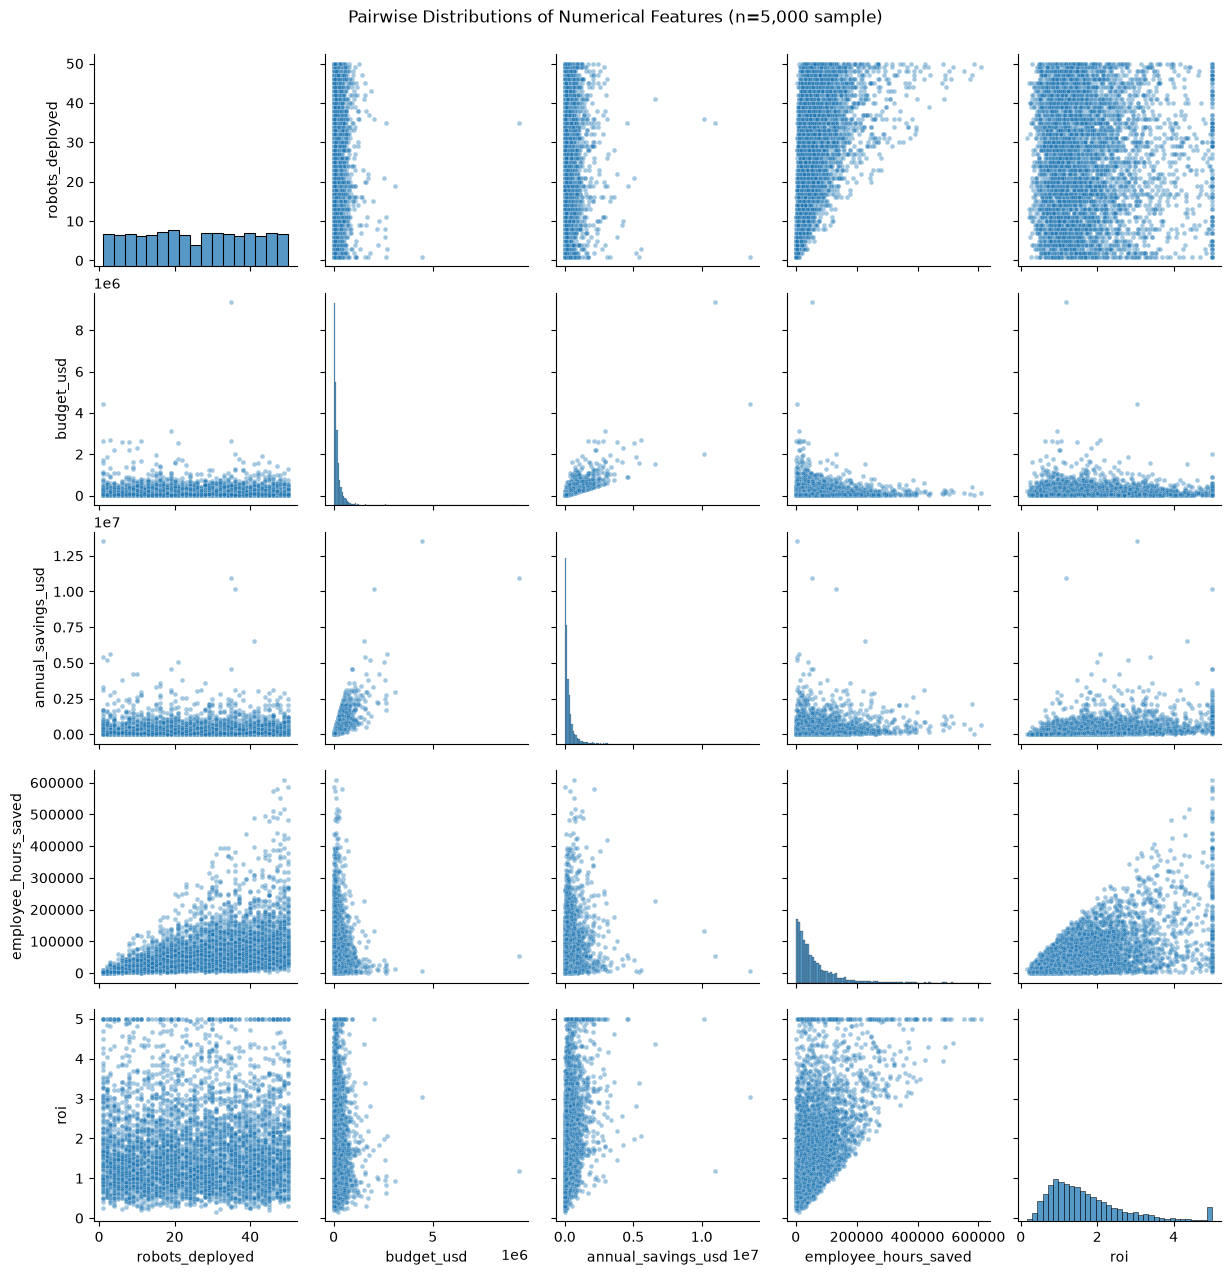

In [23]:
# Pairwise distributions of the numerical features
num_features = ['robots_deployed', 'budget_usd', 'annual_savings_usd',
                'employee_hours_saved', 'roi']

# Sample for faster rendering (50k points per panel is slow / overplotted)
sample = df[num_features].sample(n=5000, random_state=42)

sns.pairplot(sample, diag_kind='hist', plot_kws={'alpha': 0.4, 's': 12})
plt.suptitle('Pairwise Distributions of Numerical Features (n=5,000 sample)', y=1.02)
plt.show()

In [24]:
from scipy.stats import pearsonr

# Pearson correlation for selected feature pairs, computed separately for
# Overall, AI-enabled, and not-AI-enabled rows, to see whether the relationship
# differs by AI enablement. '*' marks a significant correlation (p < alpha).
alpha = 0.05

subsets = {
    'Overall': df,
    'AI=Yes': df[df['ai_enabled'] == 'Yes'],
    'AI=No':  df[df['ai_enabled'] == 'No'],
}
print("Subset sizes:", {k: len(v) for k, v in subsets.items()})


def report(title, pairs):
    print(f"\n{title}")
    header = f"{'Feature pair':<45}" + "".join(f"{name:>14}" for name in subsets)
    print(header)
    print("-" * len(header))
    for x, y in pairs:
        row = f"{x + ' / ' + y:<45}"
        for d in subsets.values():
            r, p = pearsonr(d[x], d[y])
            row += f"{r:>12.4f}{'*' if p < alpha else ' '} "
        print(row)
    print("  ('*' = significant at p < %.2f)" % alpha)


# Pairs whose trend is fairly visible in the pairplot
visible_pairs = [
    ('robots_deployed', 'employee_hours_saved'),
    ('budget_usd', 'annual_savings_usd'),
    ('annual_savings_usd', 'roi'),
    ('employee_hours_saved', 'roi'),
]
report("Pairs with a trend visible in the pairplot:", visible_pairs)

# Pairs that are NOT visually obvious from the pairplot (weak / masked by scale & spread),
# but the Pearson test still reveals whether a real linear correlation exists
not_obvious_pairs = [
    ('annual_savings_usd', 'roi'),
    ('budget_usd', 'roi'),
    ('budget_usd', 'robots_deployed'),
    ('annual_savings_usd', 'robots_deployed'),
]
report("Pairs NOT visually obvious from the pairplot:", not_obvious_pairs)

# Remaining numerical-feature pairs not covered above — this completes all
# C(5,2) = 10 unique pairs of the 5 numerical features.
remaining_pairs = [
    ('robots_deployed', 'roi'),
    ('budget_usd', 'employee_hours_saved'),
    ('annual_savings_usd', 'employee_hours_saved'),
]
report("Remaining numerical-feature pairs (completes all 10 combinations):", remaining_pairs)

Subset sizes: {'Overall': 50000, 'AI=Yes': 27549, 'AI=No': 22451}

Pairs with a trend visible in the pairplot:
Feature pair                                        Overall        AI=Yes         AI=No
---------------------------------------------------------------------------------------
robots_deployed / employee_hours_saved             0.5194*       0.5227*       0.5153* 
budget_usd / annual_savings_usd                    0.8132*       0.8109*       0.8164* 
annual_savings_usd / roi                           0.3451*       0.3506*       0.3382* 
employee_hours_saved / roi                         0.5491*       0.5469*       0.5518* 
  ('*' = significant at p < 0.05)

Pairs NOT visually obvious from the pairplot:
Feature pair                                        Overall        AI=Yes         AI=No
---------------------------------------------------------------------------------------
annual_savings_usd / roi                           0.3451*       0.3506*       0.3382* 
budget_usd / roi

# 3. Normal Distribution Test

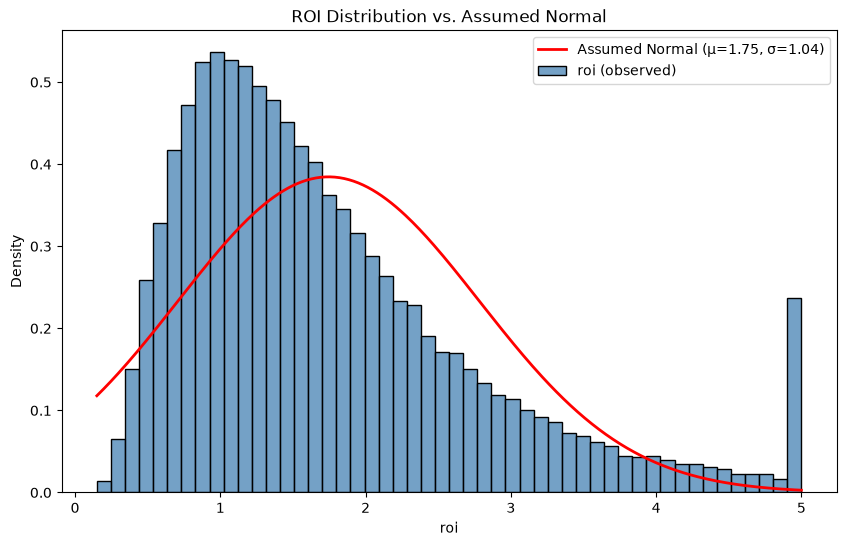

In [25]:
from scipy.stats import norm

# ROI histogram vs. the normal distribution it would have IF it were Gaussian
# (same mean & std). Visual companion to the Shapiro-Wilk test below.
roi = df['roi']
mu, sigma = roi.mean(), roi.std()

plt.figure(figsize=(10, 6))
sns.histplot(roi, bins=50, stat='density', color='steelblue', label='roi (observed)')

x = np.linspace(roi.min(), roi.max(), 300)
plt.plot(x, norm.pdf(x, mu, sigma), color='red', linewidth=2,
         label=f'Assumed Normal (μ={mu:.2f}, σ={sigma:.2f})')

plt.title('ROI Distribution vs. Assumed Normal')
plt.xlabel('roi')
plt.ylabel('Density')
plt.legend()
plt.show()

In [26]:
from scipy.stats import shapiro

# Shapiro-Wilk normality test for the 'roi' column.
# H0: the data is drawn from a normal distribution.
# p < 0.05  => reject H0 => NOT normally distributed.
# Note: Shapiro-Wilk is unreliable for n > 5000, so we test a random 5,000-row sample.
roi_sample = df['roi'].sample(n=5000, random_state=42)
stat, p = shapiro(roi_sample)

alpha = 0.05
print("Shapiro-Wilk normality test on 'roi' (random sample, n=5,000)")
print(f"  W statistic: {stat:.4f}")
print(f"  p-value:     {p:.3e}")
if p < alpha:
    print(f"  => p < {alpha}: reject H0 -> roi is NOT normally distributed")
else:
    print(f"  => p >= {alpha}: fail to reject H0 -> roi is consistent with a normal distribution")

Shapiro-Wilk normality test on 'roi' (random sample, n=5,000)
  W statistic: 0.8893
  p-value:     6.107e-51
  => p < 0.05: reject H0 -> roi is NOT normally distributed


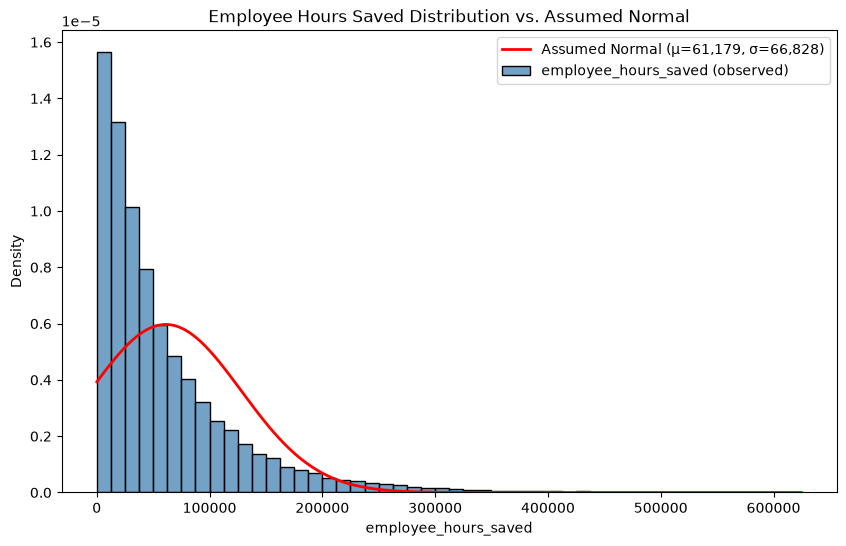

In [27]:
# employee_hours_saved histogram vs. the normal distribution it would have IF
# it were Gaussian (same mean & std). Visual companion to the Shapiro-Wilk test below.
ehs = df['employee_hours_saved']
mu, sigma = ehs.mean(), ehs.std()

plt.figure(figsize=(10, 6))
sns.histplot(ehs, bins=50, stat='density', color='steelblue', label='employee_hours_saved (observed)')

x = np.linspace(ehs.min(), ehs.max(), 300)
plt.plot(x, norm.pdf(x, mu, sigma), color='red', linewidth=2,
         label=f'Assumed Normal (μ={mu:,.0f}, σ={sigma:,.0f})')

plt.title('Employee Hours Saved Distribution vs. Assumed Normal')
plt.xlabel('employee_hours_saved')
plt.ylabel('Density')
plt.legend()
plt.show()

In [28]:
# Shapiro-Wilk normality test for the 'employee_hours_saved' column.
# H0: the data is drawn from a normal distribution.
# p < 0.05  => reject H0 => NOT normally distributed.
# Note: Shapiro-Wilk is unreliable for n > 5000, so we test a random 5,000-row sample.
ehs_sample = df['employee_hours_saved'].sample(n=5000, random_state=42)
stat, p = shapiro(ehs_sample)

alpha = 0.05
print("Shapiro-Wilk normality test on 'employee_hours_saved' (random sample, n=5,000)")
print(f"  W statistic: {stat:.4f}")
print(f"  p-value:     {p:.3e}")
if p < alpha:
    print(f"  => p < {alpha}: reject H0 -> employee_hours_saved is NOT normally distributed")
else:
    print(f"  => p >= {alpha}: fail to reject H0 -> employee_hours_saved is consistent with a normal distribution")

Shapiro-Wilk normality test on 'employee_hours_saved' (random sample, n=5,000)
  W statistic: 0.7482
  p-value:     5.064e-66
  => p < 0.05: reject H0 -> employee_hours_saved is NOT normally distributed


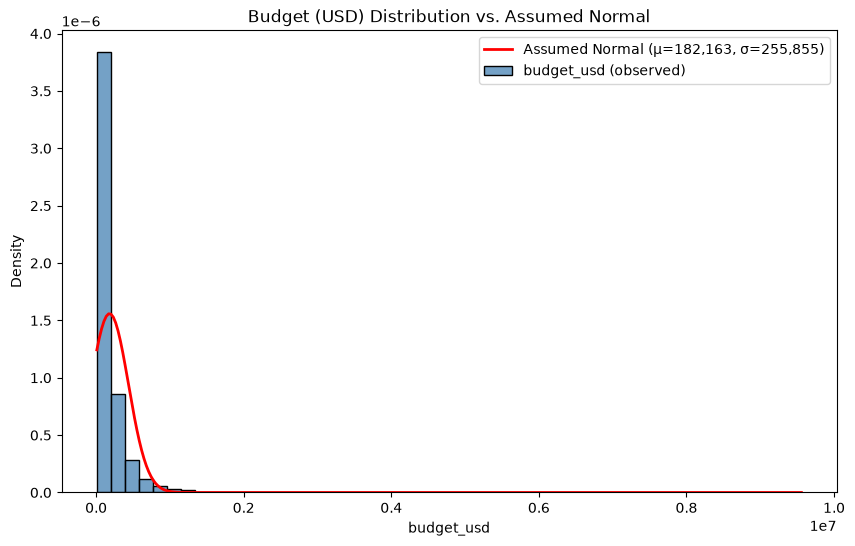

In [29]:
# budget_usd histogram vs. the normal distribution it would have IF it were
# Gaussian (same mean & std). Visual companion to the Shapiro-Wilk test below.
bud = df['budget_usd']
mu, sigma = bud.mean(), bud.std()

plt.figure(figsize=(10, 6))
sns.histplot(bud, bins=50, stat='density', color='steelblue', label='budget_usd (observed)')

x = np.linspace(bud.min(), bud.max(), 300)
plt.plot(x, norm.pdf(x, mu, sigma), color='red', linewidth=2,
         label=f'Assumed Normal (μ={mu:,.0f}, σ={sigma:,.0f})')

plt.title('Budget (USD) Distribution vs. Assumed Normal')
plt.xlabel('budget_usd')
plt.ylabel('Density')
plt.legend()
plt.show()

In [30]:
# Shapiro-Wilk normality test for the 'budget_usd' column.
# H0: the data is drawn from a normal distribution.
# p < 0.05  => reject H0 => NOT normally distributed.
# Note: Shapiro-Wilk is unreliable for n > 5000, so we test a random 5,000-row sample.
bud_sample = df['budget_usd'].sample(n=5000, random_state=42)
stat, p = shapiro(bud_sample)

alpha = 0.05
print("Shapiro-Wilk normality test on 'budget_usd' (random sample, n=5,000)")
print(f"  W statistic: {stat:.4f}")
print(f"  p-value:     {p:.3e}")
if p < alpha:
    print(f"  => p < {alpha}: reject H0 -> budget_usd is NOT normally distributed")
else:
    print(f"  => p >= {alpha}: fail to reject H0 -> budget_usd is consistent with a normal distribution")

Shapiro-Wilk normality test on 'budget_usd' (random sample, n=5,000)
  W statistic: 0.4829
  p-value:     7.036e-81
  => p < 0.05: reject H0 -> budget_usd is NOT normally distributed


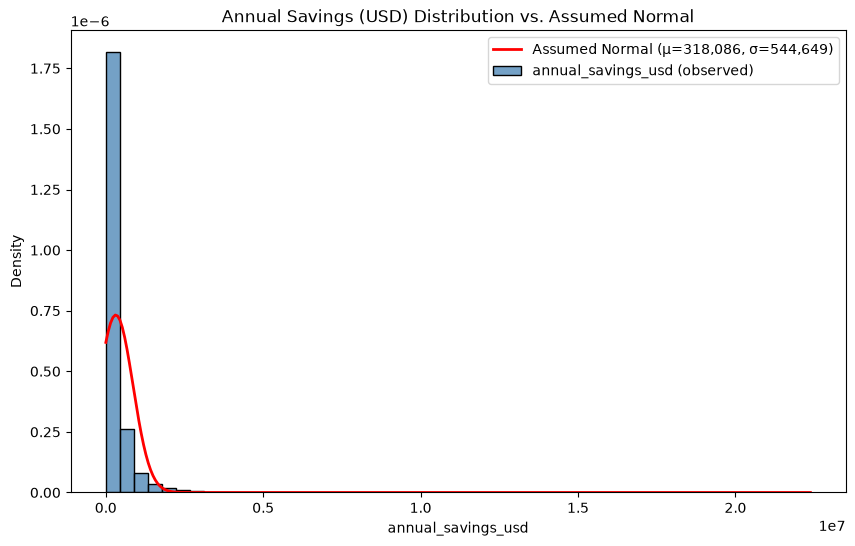

In [31]:
# annual_savings_usd histogram vs. the normal distribution it would have IF it
# were Gaussian (same mean & std). Visual companion to the Shapiro-Wilk test below.
sav = df['annual_savings_usd']
mu, sigma = sav.mean(), sav.std()

plt.figure(figsize=(10, 6))
sns.histplot(sav, bins=50, stat='density', color='steelblue', label='annual_savings_usd (observed)')

x = np.linspace(sav.min(), sav.max(), 300)
plt.plot(x, norm.pdf(x, mu, sigma), color='red', linewidth=2,
         label=f'Assumed Normal (μ={mu:,.0f}, σ={sigma:,.0f})')

plt.title('Annual Savings (USD) Distribution vs. Assumed Normal')
plt.xlabel('annual_savings_usd')
plt.ylabel('Density')
plt.legend()
plt.show()

In [32]:
# Shapiro-Wilk normality test for the 'annual_savings_usd' column.
# H0: the data is drawn from a normal distribution.
# p < 0.05  => reject H0 => NOT normally distributed.
# Note: Shapiro-Wilk is unreliable for n > 5000, so we test a random 5,000-row sample.
sav_sample = df['annual_savings_usd'].sample(n=5000, random_state=42)
stat, p = shapiro(sav_sample)

alpha = 0.05
print("Shapiro-Wilk normality test on 'annual_savings_usd' (random sample, n=5,000)")
print(f"  W statistic: {stat:.4f}")
print(f"  p-value:     {p:.3e}")
if p < alpha:
    print(f"  => p < {alpha}: reject H0 -> annual_savings_usd is NOT normally distributed")
else:
    print(f"  => p >= {alpha}: fail to reject H0 -> annual_savings_usd is consistent with a normal distribution")

Shapiro-Wilk normality test on 'annual_savings_usd' (random sample, n=5,000)
  W statistic: 0.4702
  p-value:     2.101e-81
  => p < 0.05: reject H0 -> annual_savings_usd is NOT normally distributed


# 4. P-hacking

In [33]:
# Step 1. Generate deliberately UNRELATED random columns.
# Every column is independent Gaussian noise — by construction there is NO real
# relationship between any two of them. Any correlation we find is pure chance.
rng = np.random.default_rng(7)

n_rows = 200      # small-ish n => spurious correlations look bigger / more "impressive"
n_cols = 50       # 50 columns => 50*49/2 = 1225 pairs to fish through

noise = pd.DataFrame(
    rng.standard_normal((n_rows, n_cols)),
    columns=[f"x{i:02d}" for i in range(n_cols)],
)
print(f"Generated {n_cols} independent random columns x {n_rows} rows (all pure noise).")
noise.iloc[:5, :6]

Generated 50 independent random columns x 200 rows (all pure noise).


,x00,x01,x02,x03,x04,x05
0,0.001230,0.298746,-0.274138,-0.890592,-0.454671,-0.991647
1,0.762260,-1.199289,0.074516,0.576690,-0.188782,0.682910
2,-0.304477,-0.899928,0.164053,2.244757,-0.831723,-0.623944
3,-0.694404,-0.326685,-0.560231,0.007959,-0.375267,-0.299922
4,-1.246593,0.861723,0.493932,0.873619,1.879008,1.484445


In [34]:
# Step 2. Fish through EVERY pair and keep the most "impressive" correlation.
from itertools import combinations

rows = []
for a, b in combinations(noise.columns, 2):
    r, p = pearsonr(noise[a], noise[b])
    rows.append((a, b, r, p))
pairs = pd.DataFrame(rows, columns=['a', 'b', 'r', 'p'])

n_pairs = len(pairs)
n_sig = int((pairs['p'] < 0.05).sum())
print(f"Pairs tested:                       {n_pairs}")
print(f"'Significant' at p < 0.05 by chance: {n_sig}  ({n_sig / n_pairs * 100:.1f}%)")
print(f"Expected false positives at 5%:     ~{0.05 * n_pairs:.0f}")

best = pairs.loc[pairs['r'].abs().idxmax()]
print("\n>>> The most 'impressive' correlation we 'found' in pure noise:")
print(f"    {best['a']} vs {best['b']}:   r = {best['r']:.3f},   p = {best['p']:.5f}")

Pairs tested:                       1225
'Significant' at p < 0.05 by chance: 70  (5.7%)
Expected false positives at 5%:     ~61

>>> The most 'impressive' correlation we 'found' in pure noise:
    x26 vs x37:   r = -0.224,   p = 0.00140


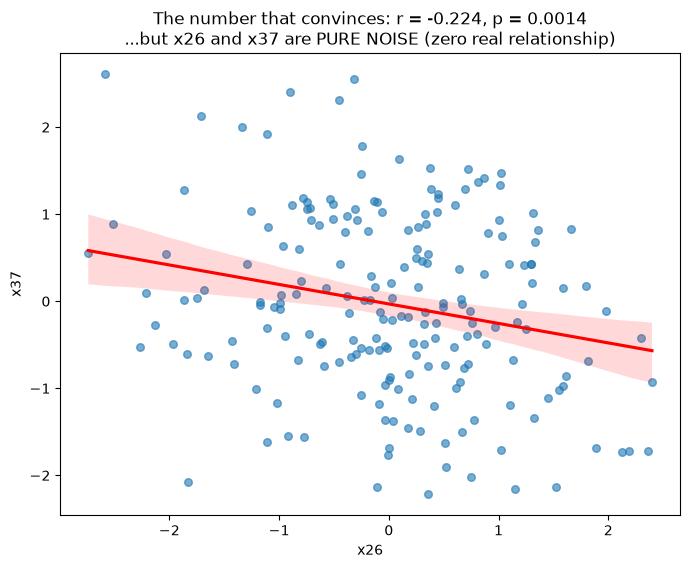

In [35]:
# Step 3. The picture that CONVINCES — a clean trend line with a "significant" p.
# Nothing here is real: both axes are independent random noise.
a, b = best['a'], best['b']

plt.figure(figsize=(8, 6))
sns.regplot(x=noise[a], y=noise[b],
            scatter_kws={'alpha': 0.6, 's': 30},
            line_kws={'color': 'red'})
plt.title(f"The number that convinces: r = {best['r']:.3f}, p = {best['p']:.4f}\n"
          f"...but {a} and {b} are PURE NOISE (zero real relationship)")
plt.xlabel(a)
plt.ylabel(b)
plt.show()

In [36]:
# Step 5. Why "R^2 = 0.99 lies": the multiple-comparisons trap, scaled up to a model.
# Predict a RANDOM target from many RANDOM predictors (none are related to y).
# With enough predictors the model "memorises" the training rows -> R^2 looks great,
# but on unseen rows it explains nothing. That is overfitting.
m = 200          # rows
k = 150          # random predictors (close to the training size -> heavy overfit)

X = rng.standard_normal((m, k))
y = rng.standard_normal(m)                    # target is independent of X
Xb = np.column_stack([np.ones(m), X])         # add intercept

tr, te = slice(0, 150), slice(150, 200)       # train / hold-out split
beta, *_ = np.linalg.lstsq(Xb[tr], y[tr], rcond=None)


def r2(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot


r2_train = r2(y[tr], Xb[tr] @ beta)
r2_test = r2(y[te], Xb[te] @ beta)
print(f"In-sample  R^2 (training):  {r2_train:.3f}   <- looks brilliant, 'the model works!'")
print(f"Out-of-sample R^2 (holdout): {r2_test:.3f}   <- the truth: it learned NOTHING")
print("\nSame mechanism as the correlation hunt: enough free parameters / enough")
print("attempts will always fit the noise. Trust out-of-sample numbers, not pretty ones.")

In-sample  R^2 (training):  1.000   <- looks brilliant, 'the model works!'
Out-of-sample R^2 (holdout): -119.930   <- the truth: it learned NOTHING

Same mechanism as the correlation hunt: enough free parameters / enough
attempts will always fit the noise. Trust out-of-sample numbers, not pretty ones.


# Conclusion

This notebook treated the dataset as a *suspect*, not a source of truth: every number was checked for whether it could be believed. Four threads came together.

### 1. Annual savings — the real driver, and a mean that lies
- **`automation_type` is the dominant driver of savings.** Three types — **Compliance Monitoring, Claims Processing, Fraud Detection** — average **~$560–567k**, roughly **2×** every other type (~$280k). They also dominate the high-savings outliers.
- **The mean overstates the typical project.** Mean annual savings (**$318k**) is ~2× the median (**$158k**) — a classic right-skew signature, so the *median* is the honest "typical" figure.
- **Outliers were detected the right way.** Rather than assume normality, we **tested it first** (Shapiro–Wilk: W = 0.47, p ≈ 0 → *not* normal) and therefore used the **IQR rule** instead of the 3σ rule. The IQR rule flags everything above **~$772k → 4,534 outliers (9.07%)**, vs. only 864 (1.7%) under the mis-calibrated 3σ threshold. On skewed data the assumption you make *is* the result.

### 2. Correlations — a few real links, the rest noise
- Strongest: **`budget_usd ↔ annual_savings_usd` (r = 0.81)**. A moderate cluster follows (`robots ↔ hours` 0.52, `hours ↔ roi` 0.55, `savings ↔ roi` 0.35, `savings ↔ hours` 0.19); the remaining numeric pairs are ≈ 0.
- **Every correlation is identical whether AI is on or off** (differences only in the 3rd decimal) — AI does not change the structure of the data.
- At **n = 50,000 the p-value is useless as a filter** (even trivial correlations are "significant"); the **effect size** is what carries meaning. And correlation ≠ causation — `automation_type` is the likely confounder behind the savings relationships.

### 3. Distributions — nothing is normal
- `roi`, `employee_hours_saved`, `budget_usd`, and `annual_savings_usd` **all fail Shapiro–Wilk** (p ≈ 0; W from 0.47 to 0.89). The skew survives outlier removal and log transforms, so it is **intrinsic, not outlier-driven** — which is exactly why the IQR rule above is the appropriate choice.

### 4. AI / cloud — mostly an illusion
- Cloud raised average savings in only **44%** of automation types (a coin-flip; +0.17% overall); AI in **72%**, but with tiny, inconsistent magnitudes (its single biggest effect is *negative*). Neither is a dependable driver of savings.

### The p-hacking lesson (the most valuable finding)
Fishing through **1,225 pure-noise pairs** produced **70 "significant"** correlations by chance; the "best" (r = −0.22, p = 0.001) looked convincing on a scatter plot but meant nothing, Bonferroni dissolved a "significant" t-test, and a random-on-random regression scored **in-sample R² = 1.00 but out-of-sample R² ≈ −120**. This is *why* models overfit and "R² = 0.99" can lie — and it's the day's real takeaway: **the most valuable discovery isn't what the data said, but where it nearly fooled us.**

### Bottom line & caveats
- **Decision-grade conclusions:** automation type drives savings; budget predicts savings; the typical project saves ~$158k (median, not the $318k mean). Everything attributed to AI or cloud sits within noise.
- **Method discipline that made it trustworthy:** test normality before choosing an outlier rule; judge correlations by effect size, not p-value; verify out-of-sample, not in-sample.
- **Caveats:** the dataset looks **synthetic** (clean r = 0.81, near-uniform category shares), so findings may reflect the generator rather than reality; and **`completion_date` is ~30% missing** (structurally, for Active/Planned projects), so any duration analysis would be biased toward completed work.